In [7]:
import requests
import pandas as pd
import google.generativeai as genai
import enum
from typing_extensions import TypedDict
import json
import plotly.express as px

In [ ]:
# Replace with your Bluesky handle and password
BLUESKY_HANDLE = #your bluesky handle
BLUESKY_PASSWORD = #your bluesky password

# Replace with your Google AI Studio API key
genai.configure(api_key=#your google gemini api key goes here)

In [15]:
model = genai.GenerativeModel("gemini-1.5-flash") # gemini-1.5-flash-exp

In [ ]:
search_term = #the company you wanna search

In [19]:
n=5

In [21]:
# Authenticate and obtain access token
auth_response = requests.post(
    'https://bsky.social/xrpc/com.atproto.server.createSession',
    json={'identifier': BLUESKY_HANDLE, 'password': BLUESKY_PASSWORD}
)
auth_response.raise_for_status()
access_token = auth_response.json().get('accessJwt')

In [23]:
# Set up the request headers with the access token
headers = {'Authorization': f'Bearer {access_token}'}

# Define the search parameters
params = {
    'q': search_term,
    'sort': 'latest',
    'limit': n
}

# Perform the search request
search_response = requests.get(
    'https://bsky.social/xrpc/app.bsky.feed.searchPosts',
    headers=headers,
    params=params
)
search_response.raise_for_status()
posts = search_response.json().get('posts', [])

In [25]:
# Extract data and create a list of dictionaries
data = []
for post in posts:
    author = post.get('author', {}).get('handle', 'Unknown')
    content = post.get('record', {}).get('text', 'No content')
    created_at = post.get('record', {}).get('createdAt', 'Unknown date')
    data.append({'Date': created_at, 'Content': content, 'Author': author})

# Convert list of dictionaries to DataFrame
df = pd.DataFrame(data)

# Convert 'Date' column to datetime format for better handling
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [27]:
# Display the DataFrame
df[['Date','Content']]

,Date,Content
0,2025-05-18 15:53:25.261000+00:00,I remember reading an article not too long ago...
1,2025-05-18 15:50:44.824000+00:00,Microsoft is working on a new Settings section...
2,2025-05-18 15:50:07.636179900+00:00,"Microsoft Xbox + USB-C Cable Carbon Black , Wi..."
3,2025-05-18 15:50:01.191000+00:00,Loving Walton Goggins's penis in The Righteous...
4,2025-05-18 15:49:28.018000+00:00,Microsoft’s Satya Nadella is choosing chatbots...


In [29]:
class Sentiment(enum.Enum):
    POSITIVE = "positive"
    NEGATIVE = "negative"
    NEUTRAL = "neutral"

class AnalysisResult(TypedDict):
    is_stock_related: bool
    sentiment: Sentiment

In [31]:
def analyze_post(content: str) -> AnalysisResult:
    prompt = f"""
    Analyze the following post and determine:
    1. Whether it is related to the company, {search_term}, and relates to or discusses 
        past, current, or future stock performance of {search_term} explicitly.
    2. If related, classify the sentiment as positive, negative, or neutral.

    Post: "{content}"
    """
    response = model.generate_content(
        prompt,
        generation_config=genai.GenerationConfig(
            response_mime_type="application/json",
            response_schema=AnalysisResult
        )
    )
    if response.candidates:
        candidate_content = response.candidates[0].content
        result_text = ''.join(part.text for part in candidate_content.parts)
        try:
            result = json.loads(result_text)
            is_stock_related = result.get('is_stock_related')
            sentiment = result.get('sentiment')
            if is_stock_related is not None and sentiment is not None:
                return is_stock_related, sentiment
            else:
                print("Missing expected keys in the response")
                return None, None
        except json.JSONDecodeError:
            print("Failed to decode JSON response")
            return None, None
    else:
        print("No candidates returned")
        return None, None

In [33]:
# Apply the analysis to each post
df[['is_stock_related', 'sentiment']] = df['Content'].apply(
    lambda x: pd.Series(analyze_post(x))
)

In [35]:
df.drop(columns='Author',inplace=True)
df

,Date,Content,is_stock_related,sentiment
0,2025-05-18 15:53:25.261000+00:00,I remember reading an article not too long ago...,True,positive
1,2025-05-18 15:50:44.824000+00:00,Microsoft is working on a new Settings section...,False,neutral
2,2025-05-18 15:50:07.636179900+00:00,"Microsoft Xbox + USB-C Cable Carbon Black , Wi...",False,neutral
3,2025-05-18 15:50:01.191000+00:00,Loving Walton Goggins's penis in The Righteous...,False,neutral
4,2025-05-18 15:49:28.018000+00:00,Microsoft’s Satya Nadella is choosing chatbots...,False,neutral


C:\Users\tejac\AppData\Local\Temp\ipykernel_2520\1867491886.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



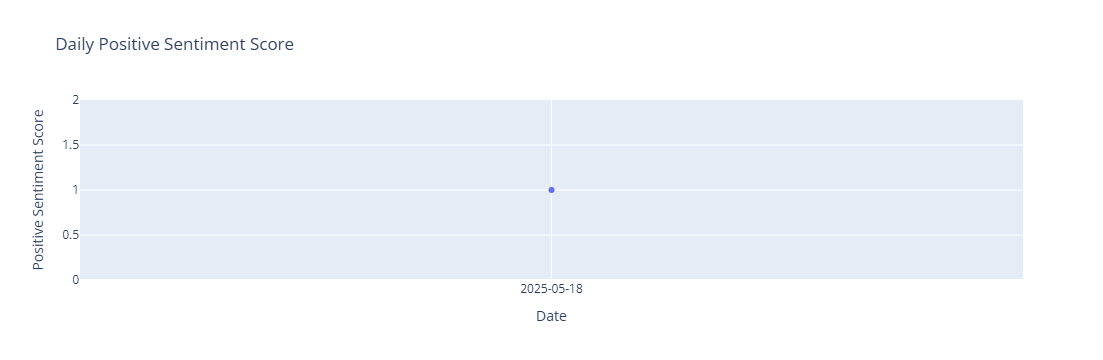

In [39]:
# Filter out neutral sentiment
filtered_df = df[df['sentiment'] != 'neutral']

# Extract the date (day only) and calculate daily positive sentiment score
filtered_df['Day'] = filtered_df['Date'].dt.date
daily_sentiment = (
    filtered_df.groupby('Day')['sentiment']
    .apply(lambda x: (x == 'positive').sum() / len(x))
    .reset_index(name='positive_sentiment_score')
)

# Plot the daily sentiment score
fig = px.line(
    daily_sentiment,
    x='Day',
    y='positive_sentiment_score',
    title='Daily Positive Sentiment Score',
    labels={'positive_sentiment_score': 'Positive Sentiment Score', 'Day': 'Date'},
    markers=True,
)

fig.update_xaxes(dtick="D", tickformat="%Y-%m-%d")


fig